Training data shape: (341, 27, 1)
Testing data shape: (86, 27, 1)
Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6481 - loss: 0.6590 - val_accuracy: 0.8488 - val_loss: 0.5576
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7683 - loss: 0.5483 - val_accuracy: 0.8488 - val_loss: 0.4706
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7947 - loss: 0.5078 - val_accuracy: 0.8721 - val_loss: 0.4149
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8182 - loss: 0.4460 - val_accuracy: 0.8721 - val_loss: 0.3960
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8182 - loss: 0.4493 - val_accuracy: 0.8837 - val_loss: 0.3551
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8358 - loss: 0.4135 - val_accuracy: 0.8837 - val_loss: 0.3567
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8270 - loss: 0.4155 - val_accuracy: 0.8953 - val_loss: 0.3477
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6

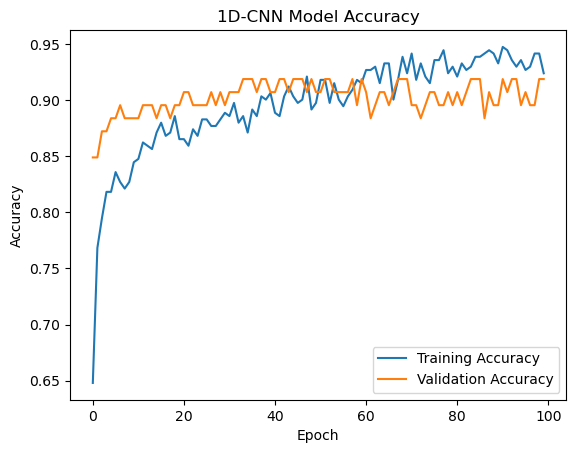

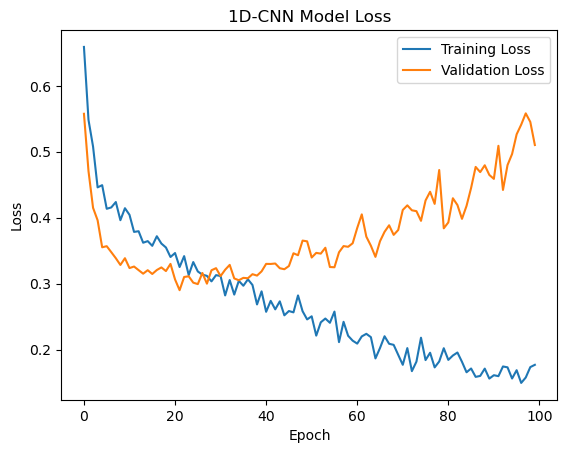

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 25, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         6,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,917 (73.90 KB)

 Trainable params: 6,305 (24.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,612 (49.27 KB)

--- Traditional Machine Learning Baselines ---
K-Nearest Neighbors (KNN) Accuracy: 88.37%


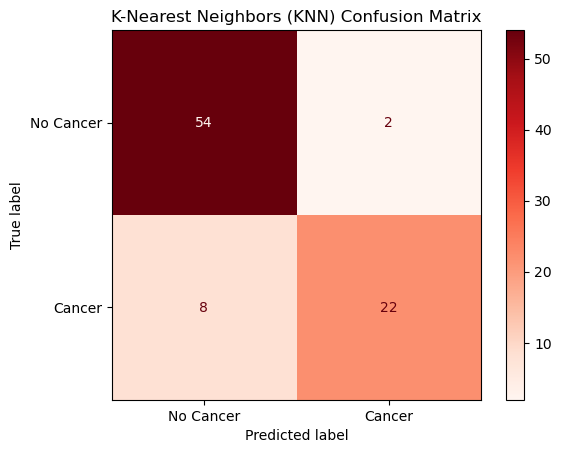

Support Vector Machine (SVM) Accuracy: 87.21%


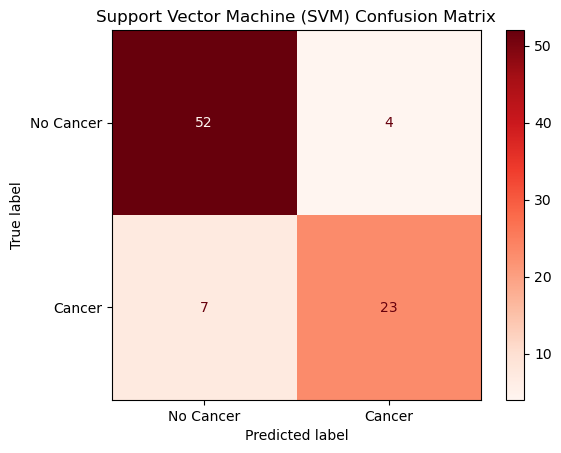

Decision Tree Accuracy: 84.88%


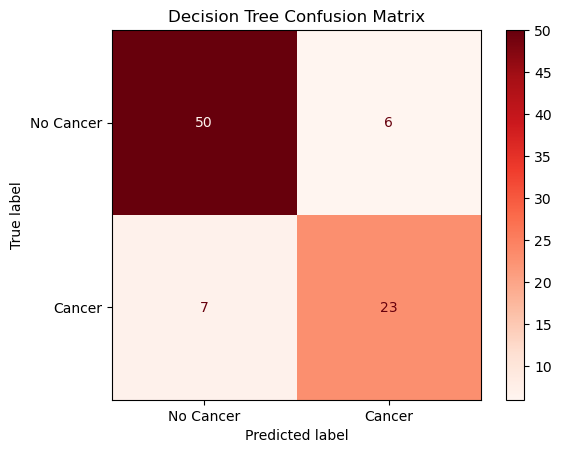

Naive Bayes Accuracy: 77.91%


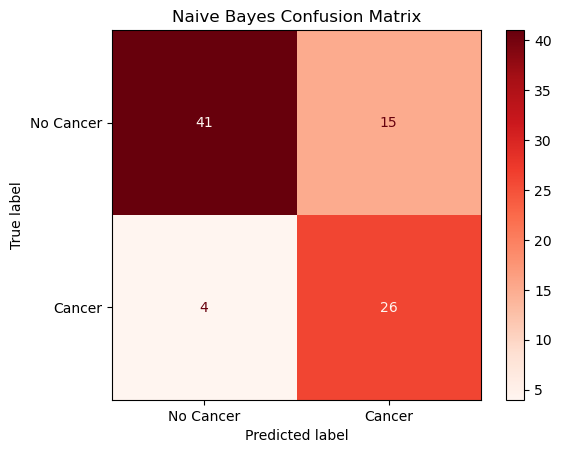

['scaler.pkl']

In [2]:
#AI(CNN) Cancer Detection by VOCs through the Exhaled Breathes
#This is the ANN Model being developed

#Import Libraries

#Baseline
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import random
import joblib

#Pre-sequence 
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

#Sequence 1 [Model ANN]
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.layers import Dropout


#Sequence 2 [Charting and Plotting]
#import matplotlib.pyplot as plt (Taken from baseline - line 12)

#Sequence 3 [Model Plotting and Diagram]
from tensorflow.keras.utils import plot_model

#Sequence 4 [For model Comperision]
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
#import matplotlib.pyplot as plt(Taken from baseline - line 12)

#Suppresses standard informational and warning messages from TensorFlow, keeping console clean. 
#Only allows error and fatal messages to print
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

#____________________________________________________________________________________________________________

#Data Preprocessing 

#Pull and Load data from Excel 
#Annotation from Dev: Data had to be cleaned at least twice. Also had to recheck data origin with source material article.
df = pd.read_excel('LungCancer_VOC_Named_Updated.xlsx')

#1. Encode Labels
df['Class'] = df['Class'].map({'Control':0,'Benign':0,'Cancer':1})

#2. Separate features (X) and target (y)
X = df.drop(['PatientID', 'Class'], axis=1).values
y = df['Class'].values

#3. Split into 80% training and 20% testing (5 parts model, 4/5 training, 1/5 testing) [Hitchhickers] 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# 4. Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Reshape for 1D-CNN input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

#____________________________________________________________________________________________________________

#Model Building and Training [Linked to Sequence 1]

# 1. Construct the 1D-CNN layers
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') 
])

# 2. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test))

#____________________________________________________________________________________________________________

#Model Evaluation and Visualization or simply Results and Plotting [Linked to Sequence 2]
# 1. Evaluate the model on testing data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

# 2. Plot accuracy curves for your report
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('1D-CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 3. Plot loss curves for your report
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('1D-CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

#____________________________________________________________________________________________________________

#Model Summary and Visualization or Architecture Export (Sequence 3)
# 1. Text-based pattern summary
model.summary()

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

plot_model(model, 
           to_file='1D_CNN_Architecture.png', 
           show_shapes=True, 
           show_layer_names=True, 
           show_layer_activations=True)

#____________________________________________________________________________________________________________

#Traditional Machine Learning Baselines (Sequence 4)

# 1. Split and Scale the data 
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(X_train_ml)
X_test_scaled = scaler_ml.transform(X_test_ml)

# 2. Initialize the models
models = {
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

# 3. Train, predict, print accuracies, and plot matrices
print("--- Traditional Machine Learning Baselines ---")

# Notice the variable is now 'ml_model' so it doesn't overwrite your CNN 'model'
for name, ml_model in models.items(): 
    
    # Train and predict
    ml_model.fit(X_train_scaled, y_train_ml)
    y_pred = ml_model.predict(X_test_scaled)
    
    # Print Accuracy
    accuracy = accuracy_score(y_test_ml, y_pred)
    print(f"{name} Accuracy: {accuracy:.2%}")
    
    # Generate and plot the Confusion Matrix
    cm = confusion_matrix(y_test_ml, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancer', 'Cancer'])
    disp.plot(cmap='Reds')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
#____________________________________________________________________________________________________________

model.save('cancer_cnn_model_V3.keras')
joblib.dump(scaler, 'scaler.pkl')